# Annotation Sampling
> Goal: Draw a representative 10% sample from the full 35k dataset to serve as the annotation pool for multi-class classification (4 additional labels per sentence). The remaining 90% is untouched.

In [1]:
import os
import sys

# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# print(notebook_dir)
# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from data_visualizing import DataVisualizing

## Load Dataset

In [2]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
data_path = os.path.join(base_data_path, 'combined_datasets/synthetic-fpb-chronicle2050-yt-news-timebank-mf_climate/synthetic-fpb-chronicle2050-yt-news-timebank-mf_climate.csv')
df = DataProcessing.load_from_file(data_path)
df

,Base Sentence,Ground Truth,Dataset Name
0,JPMorgan Chase forecasts that the net profit a...,1,synthetic
1,"On August 21, 2024, Bank of America speculates...",1,synthetic
2,"Citigroup predicts on 2024-08-21, the operatin...",1,synthetic
3,"According to Goldman Sachs, the research and d...",1,synthetic
4,"In 21 August 2024, Morgan Stanley envisions th...",1,synthetic
...,...,...,...
38311,Snow showers may accompany a departing storm s...,1,mf_climate
38312,A broad upper trough will bring active weather...,1,mf_climate
38313,"In the Northwest, 3-6 inch rainfall totals are...",1,mf_climate
38314,"Additionally, moderately heavy snow is expecte...",1,mf_climate


## Visualize Full Dataset
- > Inspect class imbalance and per-dataset distribution before sampling.

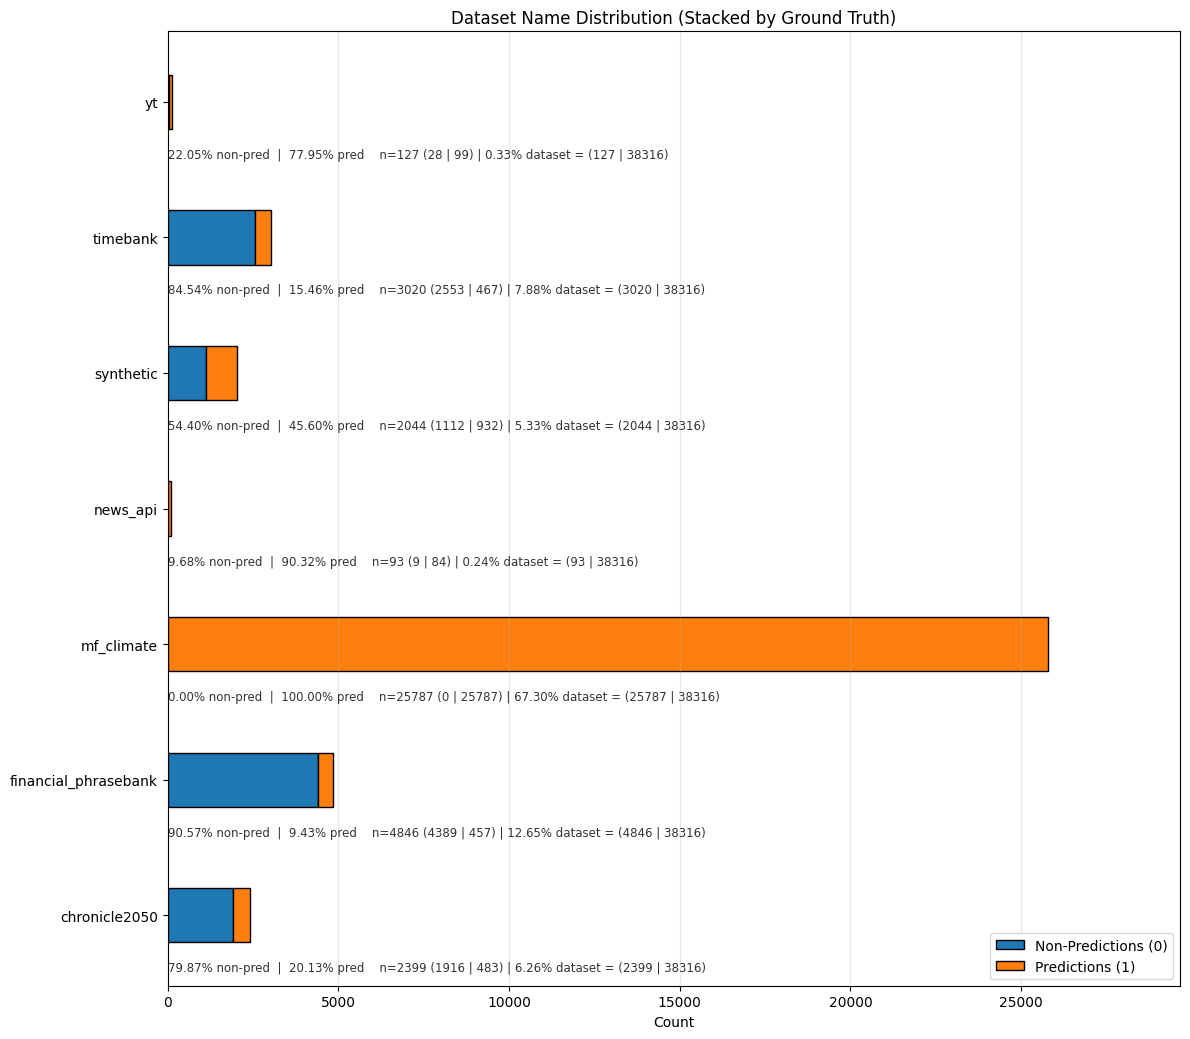


Dataset Name vs Ground Truth Breakdown:
Ground Truth             0      1
Dataset Name                     
chronicle2050         1916    483
financial_phrasebank  4389    457
mf_climate               0  25787
news_api                 9     84
synthetic             1112    932
timebank              2553    467
yt                      28     99


In [3]:
DataVisualizing.plot_stacked_distribution(
    df=df, 
    category_col='Dataset Name', 
    label_col='Ground Truth'
)

In [4]:
y_df = df[['Ground Truth']]
# y_df = df['Ground Truth']
y_df

,Ground Truth
0,1
1,1
2,1
3,1
4,1
...,...
38311,1
38312,1
38313,1
38314,1


## Sample Dataset
- > Stratified 10% sample drawn on `Ground Truth` to preserve global 0/1 class ratios.
- > Per-dataset representation follows as a natural consequence of stratification.

In [5]:
X_train, X_test, y_train, y_test = DataProcessing.split_data(
    features_df=df,
    labels_df=y_df,
    random_state=3,
    test_size=.1,
    stratify_by='Ground Truth'
)

In [6]:
X_train

,Base Sentence,Ground Truth,Dataset Name
11048,About $60 million streamed out last week alone...,0,timebank
27955,Heavy rainfall anticipated over the Southern P...,1,mf_climate
38228,A transition to a cold front is likely in the ...,1,mf_climate
25836,A stationary trough in southern California wil...,1,mf_climate
485,Dr. Emily Carter forecasts that the global sea...,1,synthetic
...,...,...,...
13341,Enhanced rainfall is likely as Gulf moisture a...,1,mf_climate
32123,Heavy rain and flooding hazards are forecast a...,1,mf_climate
34297,A prolonged heat wave will persist across the ...,1,mf_climate
12694,A significant weather pattern change is expect...,1,mf_climate


In [7]:
X_test

,Base Sentence,Ground Truth,Dataset Name
25166,"The West will also have below normal highs, bu...",1,mf_climate
31467,A shortwave trough will amplify the ridge patt...,1,mf_climate
2311,Sales are expected to increase in the end of t...,1,financial_phrasebank
4975,"Also in Latvia , we act as a partner for baker...",0,financial_phrasebank
3212,`` The margarine business has been put into go...,0,financial_phrasebank
...,...,...,...
14546,Below normal temperatures are anticipated for ...,1,mf_climate
7567,Itâs the first time an annual death toll in ...,0,chronicle2050
20670,The Pacific Northwest may see daytime temperat...,1,mf_climate
1239,The Congressional Budget Office noted that the...,0,synthetic


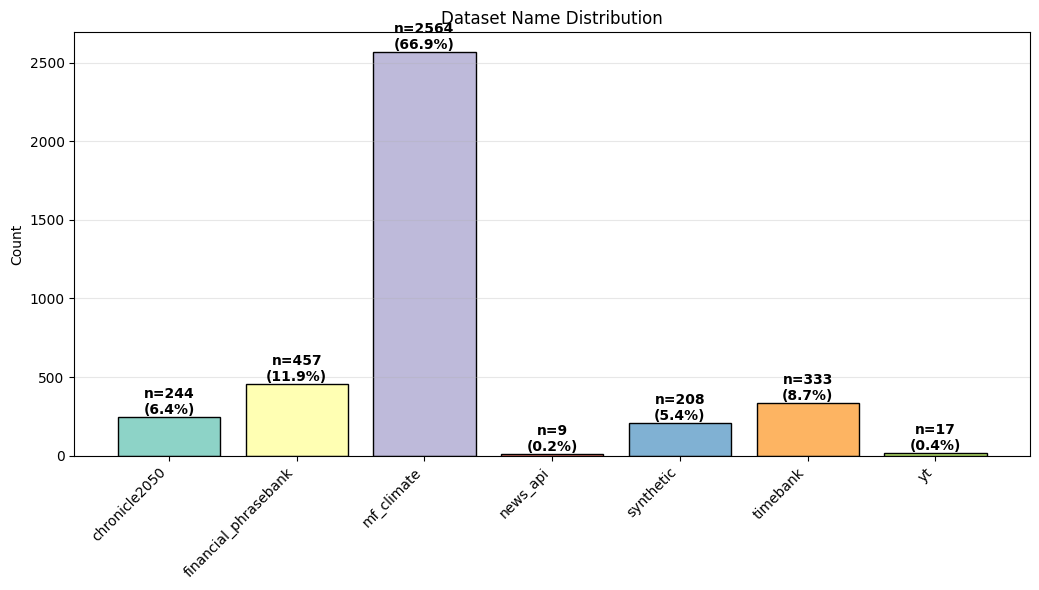

In [8]:
DataVisualizing.plot_class_distribution(
    df=X_test, 
    label_col='Dataset Name'
)

## Visualize Sample
- > Confirm the 10% sample mirrors the full dataset's distribution across `Ground Truth` labels and `Dataset Name`.
- > Note: Small datasets (e.g., `yt`, `news_api`) are underrepresented, until more are added.

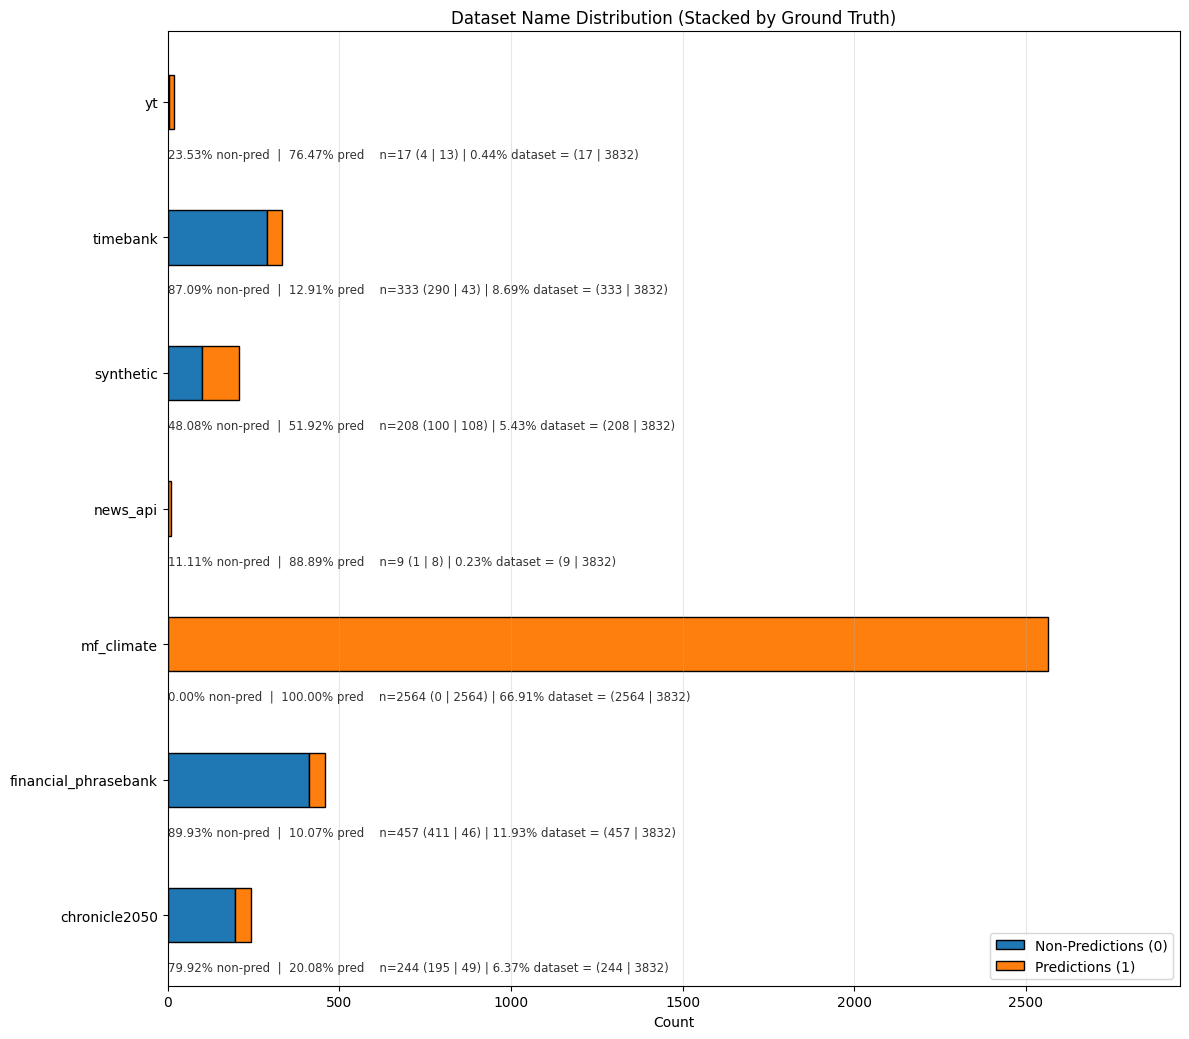


Dataset Name vs Ground Truth Breakdown:
Ground Truth            0     1
Dataset Name                   
chronicle2050         195    49
financial_phrasebank  411    46
mf_climate              0  2564
news_api                1     8
synthetic             100   108
timebank              290    43
yt                      4    13


In [9]:
DataVisualizing.plot_stacked_distribution(
    df=X_test, 
    category_col='Dataset Name', 
    label_col='Ground Truth'
)